In [1]:
# Importing the necessary libraries
import torch
from torch import optim, utils, tensor, nn

import matplotlib.pyplot as plt
from getdist import plots, MCSamples

from Network import Generator, Discriminator
from Signal_Generator import *

from tqdm import tqdm

# Setting the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
# Defining the hyperparameters
datasize = 16000
num_sources = 2
noise_amplitude = 0
freq_range = (1e-4, 1e-1)
total_time = 1000

num_latent_variables = 20
learning_rate = 1e-5
weight_clip = 0.1

d_loss_threshold = -0.1
g_loss_threshold = -0.3
threshold_adjustment = 0.025
max_steps = 300

num_epochs = 20

In [3]:
# Defining the distribution for amplitude and angular frequency
def amp_distribution(size):
    """
    Amplitude distribution using uniform distribution.
    """
    return np.random.uniform(4, 16, size=size)

def omega_distribution(size):
    """
    Angular frequency distribution using uniform distribution.
    """
    return np.random.uniform(2 * np.pi * 1e-4, 2 * np.pi * 1e-1, size=size)

In [8]:
# Creating the dataset
dataset = []

for i in range(datasize):
    SG = Signal_Generator(num_sources=num_sources, noise_amplitude=noise_amplitude, amp_distribution_func=amp_distribution, omega_distribution_func=omega_distribution, freq_range=freq_range, total_time=total_time)
    signals = SG.generating_signal()
    params = SG.printing_parameters()
    signal = signals['Signal'].values

    signal_tensor = tensor(signal, dtype=torch.float).unsqueeze(0).to(device)
    params_tensor = tensor(params, dtype=torch.float).to(device)

    dataset.append((signal_tensor, params_tensor))

train_loader = utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

In [9]:
params

[0.39215283974356535,
 0.6091739430762597,
 0.4427754805807605,
 0.3205333623931639]

In [ ]:
torch.save(dataset, 'dataset.pt')

In [12]:
# Defining the WGAN traning class
class WGAN(nn.Module):
    def __init__(self, num_latent_variables, lr, weight_clip):
        super(WGAN, self).__init__()
        self.num_latent_variables = num_latent_variables
        self.lr = lr
        self.weight_clip = weight_clip

        # Networks
        self.generator = Generator(in_channels=1, num_latent_variables=num_latent_variables, length=len(signal), num_parameters=len(params)).to(device)
        self.discriminator = Discriminator(input_channels=1, length=len(signal), num_parameters=len(params)).to(device)

        # Optimizers
        self.optimizer_g = optim.Adam(self.generator.parameters(), lr=self.lr)
        self.optimizer_d = optim.Adam(self.discriminator.parameters(), lr=self.lr)

    def wasserstein_loss(self, output_d, y):
        return torch.mean(output_d * y)

    def train_generator(self, signal_tensor, params_tensor, z):
        fake_params = self.generator(signal_tensor, z)
        fake_output = self.discriminator(signal_tensor, fake_params)
        real_output = self.discriminator(signal_tensor, params_tensor)
        g_loss = -torch.mean(fake_output)
        d_loss = -(torch.mean(real_output) - torch.mean(fake_output))

        self.optimizer_g.zero_grad()
        g_loss.backward()
        self.optimizer_g.step()

        return g_loss.item(), d_loss.item()

    def train_discriminator(self, signal_tensor, params_tensor, z):
        fake_params = self.generator(signal_tensor, z)
        fake_output = self.discriminator(signal_tensor, fake_params)
        real_output = self.discriminator(signal_tensor, params_tensor)
        g_loss = -torch.mean(fake_output)
        d_loss = -(torch.mean(real_output) - torch.mean(fake_output))

        self.optimizer_d.zero_grad()
        d_loss.backward()
        self.optimizer_d.step()

        # Weight clipping
        for p in self.discriminator.parameters():
            p.data.clamp_(-self.weight_clip, self.weight_clip)

        return g_loss.item(), d_loss.item()

In [ ]:
""" # Test training
wgan = WGAN(num_latent_variables=num_latent_variables, lr=learning_rate, weight_clip=0.1).to(device)

loss_list = []

for i in tqdm(range(100)):
    for _, (signal_tensor, params_tensor) in enumerate(train_loader):
        z = torch.randn(1, num_latent_variables, 1).to(device)
        loss = wgan.train_discriminator(signal_tensor, params_tensor, z)
        loss_list.append(loss)
    #print(f"Epoch {i}, Discriminator loss: {d_loss}")

plt.plot(loss_list, label=['Generator Loss', 'Discriminator Loss'])
plt.legend() """

In [ ]:
""" wgan = WGAN(num_latent_variables=num_latent_variables, lr=learning_rate, weight_clip=0.1).to(device)

loss_list = []

for i in tqdm(range(50)):
    for _, (signal_tensor, params_tensor) in enumerate(train_loader):
        z = torch.randn(1, num_latent_variables, 1).to(device)
        loss = wgan.train_discriminator(signal_tensor, params_tensor, z)
        loss_list.append(loss)
    #print(f"Epoch {i}, Discriminator loss: {d_loss}")

for i in tqdm(range(50)):
    for _, (signal_tensor, params_tensor) in enumerate(train_loader):
        z = torch.randn(1, num_latent_variables, 1).to(device)
        loss = wgan.train_generator(signal_tensor, params_tensor, z)
        loss_list.append(loss)
    #print(f"Epoch {i}, Discriminator loss: {d_loss}")

plt.plot(loss_list, label=['Generator Loss', 'Discriminator Loss'])
plt.legend() """

In [13]:
# Adaptive training
wgan = WGAN(num_latent_variables=num_latent_variables, lr=learning_rate, weight_clip=0.1).to(device)

loss_list = []

ncri_list = []
ngen_list = []

d_loss_threshold = -0.1
g_loss_threshold = -0.3

training_d = True

for epoch in tqdm(range(num_epochs)):
    ncri = 0
    ngen = 0
    for _, (signal_tensor, params_tensor) in enumerate(train_loader):
        z = torch.randn(1, num_latent_variables, 1).to(device)

        critic_steps = 0
        generator_steps = 0
        
        while training_d and critic_steps < max_steps:
            loss = wgan.train_discriminator(signal_tensor, params_tensor, z)
            loss_list.append(loss)
            ncri+=1
            critic_steps+=1
            if loss[0] > g_loss_threshold:
                training_d = False
                break

        if critic_steps == max_steps:
            g_loss_threshold -= threshold_adjustment

        while not training_d and generator_steps < max_steps:
            loss = wgan.train_generator(signal_tensor, params_tensor, z)
            loss_list.append(loss)
            ngen+=1
            generator_steps+=1
            if loss[1] > d_loss_threshold:
                training_d = True
                break

        if generator_steps == max_steps:
            d_loss_threshold -= threshold_adjustment

    ncri_list.append(ncri)
    ngen_list.append(ngen)

 85%|████████▌ | 17/20 [03:28<00:36, 12.27s/it]


KeyboardInterrupt: 

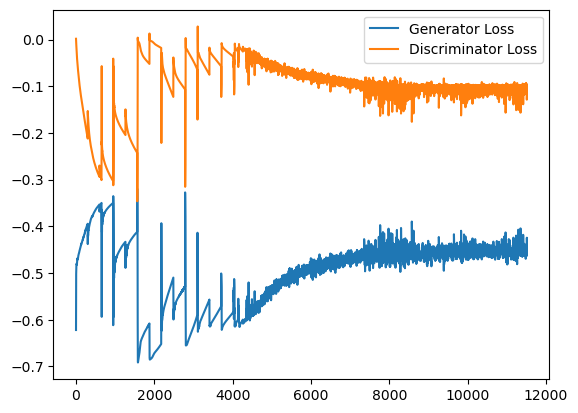

In [14]:
plt.plot(loss_list, label=['Generator Loss', 'Discriminator Loss'])
plt.legend()

In [ ]:
""" training_d = True

for epoch in tqdm(range(500)):
    ncri = 0
    ngen = 0
    for _, (signal_tensor, params_tensor) in enumerate(train_loader):
        z = torch.randn(1, num_latent_variables, 1).to(device)

        critic_steps = 0
        generator_steps = 0
        
        while training_d and critic_steps < max_steps:
            loss = wgan.train_discriminator(signal_tensor, params_tensor, z)
            loss_list.append(loss)
            ncri+=1
            critic_steps+=1
            if loss[0] > g_loss_threshold:
                training_d = False
                break

        if critic_steps == max_steps:
            g_loss_threshold -= threshold_adjustment

        while not training_d and generator_steps < max_steps:
            loss = wgan.train_generator(signal_tensor, params_tensor, z)
            loss_list.append(loss)
            ngen+=1
            generator_steps+=1
            if loss[1] > d_loss_threshold:
                training_d = True
                break

        if generator_steps == max_steps:
            d_loss_threshold -= threshold_adjustment

    ncri_list.append(ncri)
    ngen_list.append(ngen) """

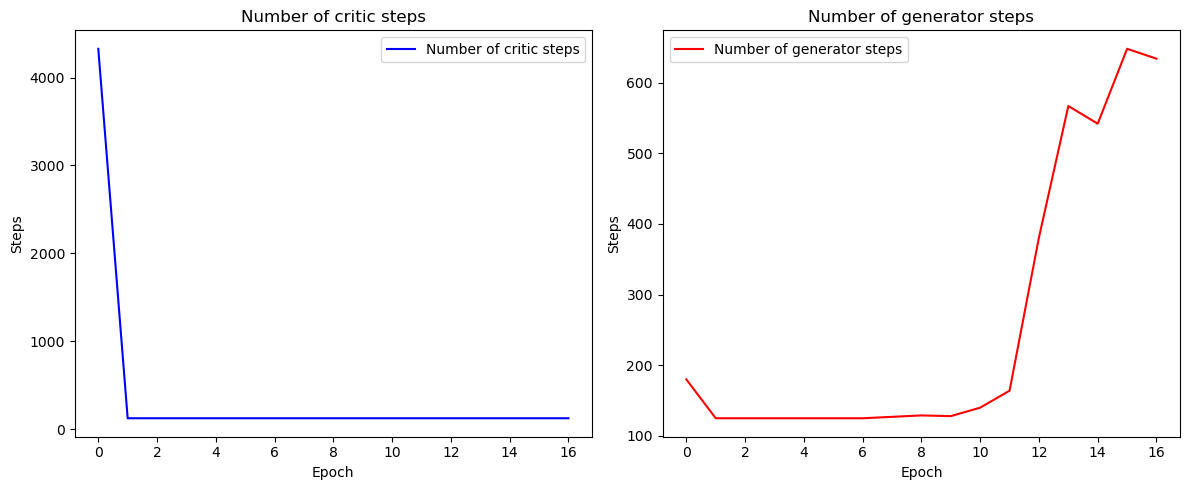

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(ncri_list, label='Number of critic steps', color='blue')
axs[0].set_title('Number of critic steps')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Steps')
axs[0].legend()

axs[1].plot(ngen_list, label='Number of generator steps', color='red')
axs[1].set_title('Number of generator steps')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Steps')
axs[1].legend()

plt.tight_layout()

In [16]:
generator = wgan.generator
discriminator = wgan.discriminator

generator.eval()

Generator(
  (init_conv): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (init_relu): LeakyReLU(negative_slope=0.2)
  (res_block_no_norm): ResBlock(
    (conv1): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
    (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (leaky_relu): LeakyReLU(negative_slope=0.2)
  )
  (down1): Conditional_Down(
    (conv): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (relu): LeakyReLU(negative_slope=0.2)
    (avg_pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
    (res_block): Conditional_ResBlock(
      (conv1): Conv1d(128, 128, kernel_size=(1,), stride=(1,))
      (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (leaky_relu): LeakyReLU(negative_slope=0.2)
      (process1): CIN(
        (inst_norm): InstanceNorm1d(

In [17]:
generated_params_list = []

TS = Signal_Generator(num_sources=num_sources, noise_amplitude=noise_amplitude, freq_range=freq_range, 
                      total_time=total_time, amp_distribution_func=amp_distribution, omega_distribution_func=omega_distribution)

test_data = TS.generating_signal()
params = TS.printing_parameters()

input_signal = test_data['Signal'].values
input_signal_tensor = torch.tensor(input_signal, dtype=torch.float).unsqueeze(0).unsqueeze(0).to(device)

for i in range(10000):
    with torch.no_grad():
        z = torch.randn(1, num_latent_variables, 1).to(device)
        generated_params = generator(input_signal_tensor, z).squeeze().cpu().numpy()
        generated_params_list.append(generated_params)

print(params)
print(generated_params_list)

columns = []
for i in range(num_sources):
    columns.extend([f'Amplitude{i+1}', f'Frequency{i+1}', f'Phase{i+1}'])

generated_params_df = pd.DataFrame(generated_params_list, columns=columns)

for i in range(num_sources):
    start_idx = i * 3
    param_slice = params[start_idx:start_idx+3]
    names = [f"A{i+1}", f"omega{i+1}", f"theta{i+1}"]
    labels = [f"Amplitude{i+1}", f"Frequency{i+1}", f"Phase{i+1}"]
    
    generated_params_samples = MCSamples(samples=generated_params_df.iloc[:, start_idx:start_idx+3].values, names=names, labels=labels, settings={'ignore_rows': 1000})
    
    generated_params_samples.updateSettings({'fine_bins_2D': 1048})
    
    g = plots.get_subplot_plotter()
    g.triangle_plot([generated_params_samples], filled=True)
    
    axes = g.subplots
    for j in range(3):
        for k in range(j + 1, 3):
            ax = axes[k, j]
            if ax is not None:
                ax.scatter(param_slice[j], param_slice[k], color='red', marker='o', s=50)
    
    for j in range(3):
        ax = axes[j, j]
        if ax is not None:
            ax.axvline(param_slice[j], linestyle='--', color='red', lw=1)
    
    handles = [plt.Line2D([0], [0], color='red', lw=2, linestyle='--', marker='o')]
    labels = ['Original Parameters']
    g.fig.legend(handles, labels, loc='upper right')
    #plt.savefig(f'triangle_plot{i+1}.png')
    #plt.close()

KeyboardInterrupt: 

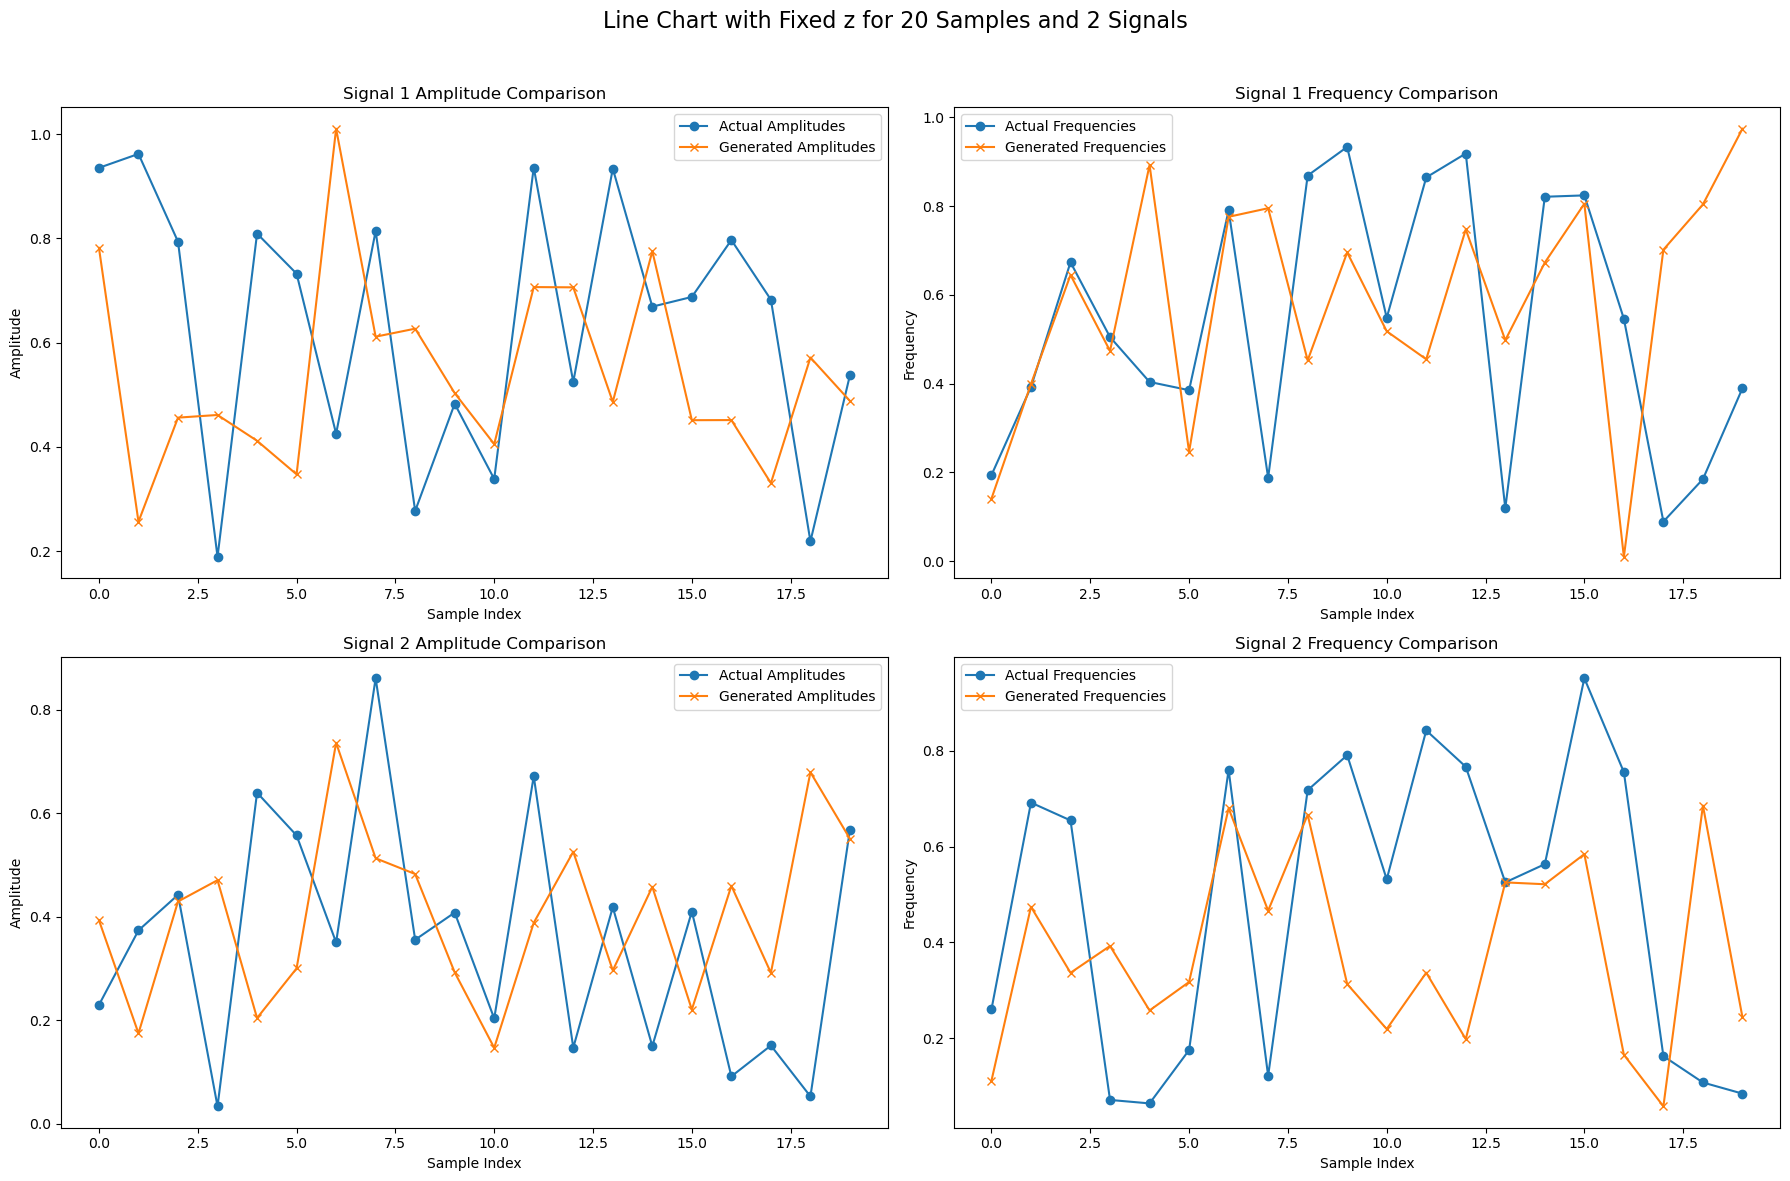

In [19]:
params_list = []
generated_params_list = []

test_times = 20
for i in range(test_times):
    TS = Signal_Generator(num_sources=num_sources, noise_amplitude=noise_amplitude, freq_range=freq_range, total_time=total_time, amp_distribution_func=amp_distribution, omega_distribution_func=omega_distribution)
    test_data = TS.generating_signal()
    params = TS.printing_parameters()

    input_signal = test_data['Signal'].values
    input_signal_tensor = torch.tensor(input_signal, dtype=torch.float).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        z = torch.randn(1, num_latent_variables, 1).to(device)
        generated_params = generator(input_signal_tensor, z).squeeze().cpu().numpy()

    params_list.append(params)
    generated_params_list.append(generated_params)

actual_amplitudes = [[] for _ in range(num_sources)]
actual_frequencies = [[] for _ in range(num_sources)]

generated_amplitudes = [[] for _ in range(num_sources)]
generated_frequencies = [[] for _ in range(num_sources)]

for params in params_list:
    for i in range(num_sources):
        actual_amplitudes[i].append(params[i*2])
        actual_frequencies[i].append(params[i*2 + 1])

for gen_params in generated_params_list:
    for i in range(num_sources):
        generated_amplitudes[i].append(gen_params[i*2])
        generated_frequencies[i].append(gen_params[i*2 + 1])

plt.figure(figsize=(18, 6 * num_sources))

for i in range(num_sources):
    plt.subplot(num_sources, 2, 2 * i + 1)
    plt.plot(range(test_times), actual_amplitudes[i], 'o-', label='Actual Amplitudes')
    plt.plot(range(test_times), generated_amplitudes[i], 'x-', label='Generated Amplitudes')
    plt.xlabel('Sample Index')
    plt.ylabel('Amplitude')
    plt.title(f'Signal {i+1} Amplitude Comparison')
    plt.legend()

    plt.subplot(num_sources, 2, 2 * i + 2)
    plt.plot(range(test_times), actual_frequencies[i], 'o-', label='Actual Frequencies')
    plt.plot(range(test_times), generated_frequencies[i], 'x-', label='Generated Frequencies')
    plt.xlabel('Sample Index')
    plt.ylabel('Frequency')
    plt.title(f'Signal {i+1} Frequency Comparison')
    plt.legend()

plt.suptitle(f'Line Chart with Fixed z for {test_times} Samples and {num_sources} Signals', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
""" torch.save(generator, 'generator_sub.pt')
torch.save(discriminator, 'discriminator_sub.pt')  """